## Decision Trees

In [36]:
# Using Titanic Dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [37]:
df = pd.read_csv("E:\AI and ML\Section Two\Assignment\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
# On a person's info we are going to predict whether they are going to survive or not.
# As can be seen in Survived column it has binary values so we are going to use binary classification, hence decision trees.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [40]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [41]:
features = ["Pclass", "Fare", "Sex", "Embarked", "Age"]
target = ["Survived"]

In [42]:
# To fill our missing values we can simply use our imputer here:
# using frequent mean, median or mode:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
df[["Age"]] = imp_median.fit_transform(df[["Age"]]) # [[]] as we are sending only one column

imp_freq = SimpleImputer(strategy="most_frequent")
df[["Embarked"]] = imp_freq.fit_transform(df[["Embarked"]])

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
df.isnull().sum()
# All columns in features are now not-null

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [45]:
df.shape

(891, 12)

# Encoding

In [46]:
# For categorical data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

df["Embarked"] = le.fit_transform(df["Embarked"])


In [47]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


# Data Split & Train-Test-Valid Phase

In [48]:
X = df[features]
y = df[target]

In [49]:
X.head()

,Pclass,Fare,Sex,Embarked,Age
0,3,7.2500,1,2,22.0
1,1,71.2833,0,0,38.0
2,3,7.9250,0,2,26.0
3,1,53.1000,0,2,35.0
4,3,8.0500,1,2,35.0


In [50]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [51]:
# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
X_train.head()

,Pclass,Fare,Sex,Embarked,Age
331,1,28.5000,1,2,45.5
733,2,13.0000,1,2,23.0
382,3,7.9250,1,2,32.0
704,3,7.8542,1,2,26.0
813,3,31.2750,0,2,6.0


In [53]:
X_test.head()

,Pclass,Fare,Sex,Embarked,Age
709,3,15.2458,1,0,28.0
439,2,10.5000,1,2,31.0
840,3,7.9250,1,2,20.0
720,2,33.0000,0,2,6.0
39,3,11.2417,0,0,14.0


In [54]:
# Decision Tree Model (No Pruning in this)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

In [56]:
print("Accuracy", accuracy_score(y_test, y_pred))

Accuracy 0.776536312849162


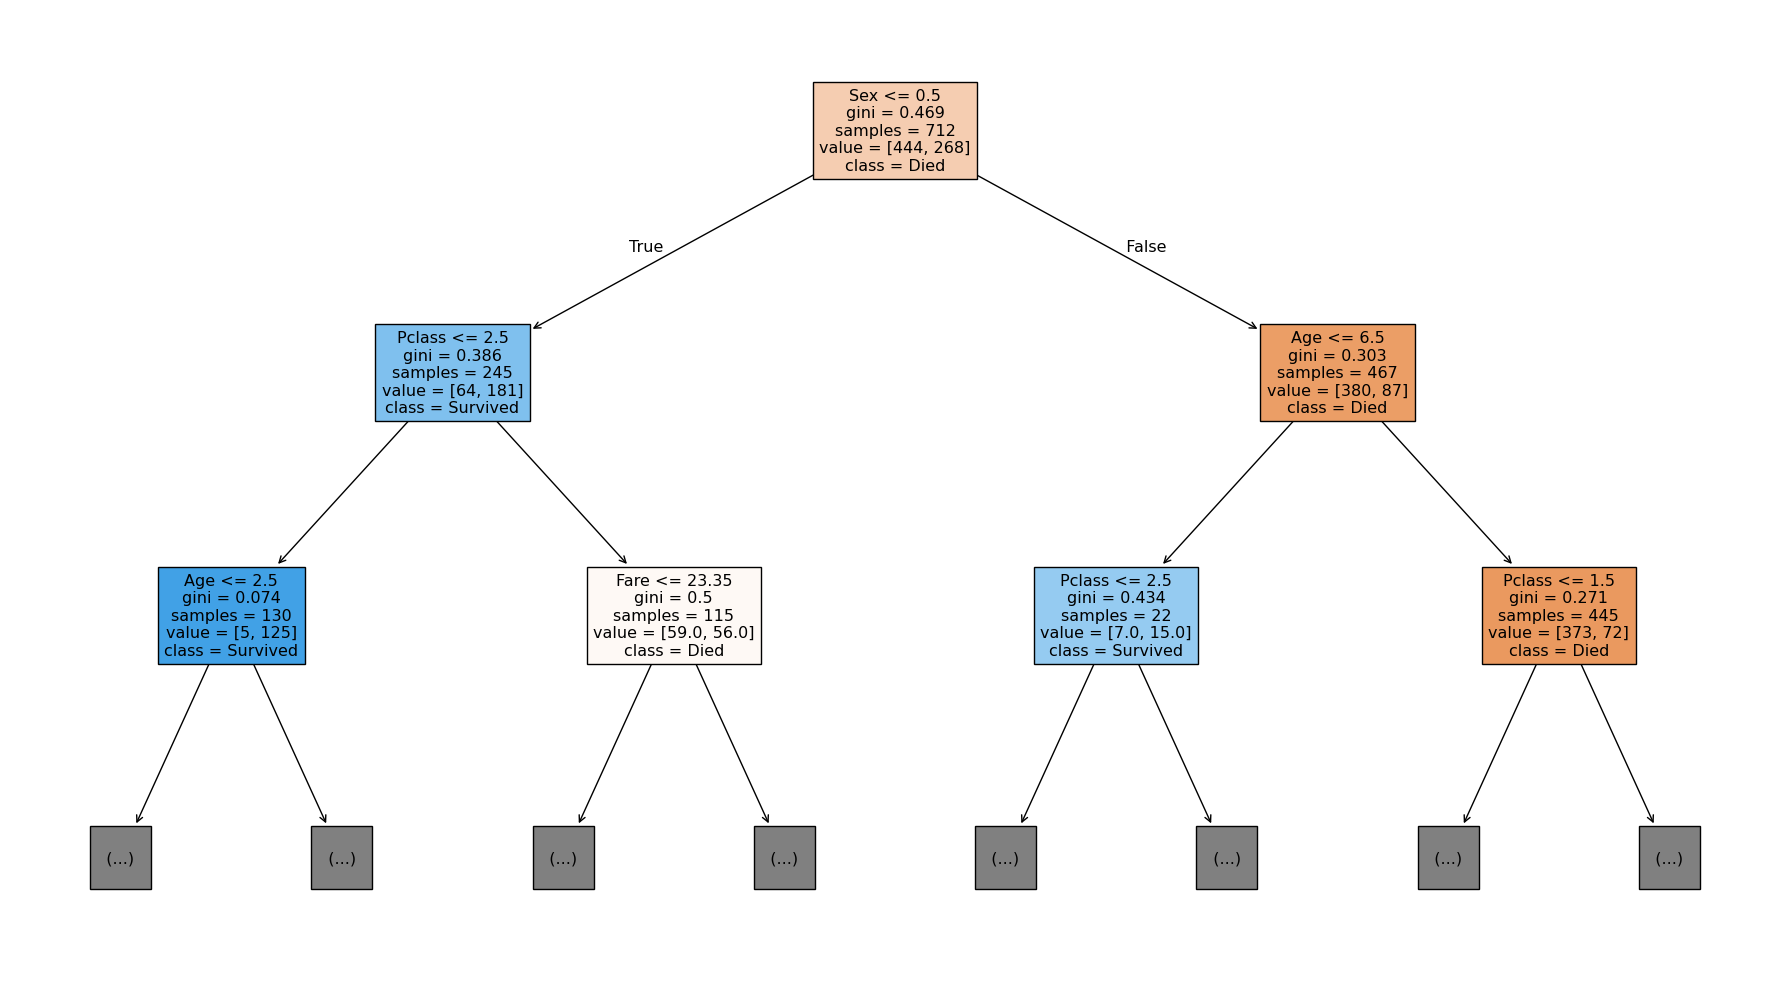

In [57]:
# To plot our Decision Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(model, feature_names = X.columns, class_names = ["Died", "Survived"], filled=True, max_depth=2)
plt.tight_layout()
plt.show()

In [58]:
# Decision Tree with Pre-Pruning

max_depths = [2, 3, 4, 5, 6, 7, 8]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy={acc}")


for depth = 2, accuracy=0.7653631284916201
for depth = 3, accuracy=0.7988826815642458
for depth = 4, accuracy=0.7988826815642458
for depth = 5, accuracy=0.7988826815642458
for depth = 6, accuracy=0.7988826815642458
for depth = 7, accuracy=0.7988826815642458
for depth = 8, accuracy=0.7932960893854749


In [59]:
min_samples_split = [5, 10, 15, 20, 25, 30, 35, 40]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for minimum samples = {split}, accuracy={acc}")


for minimum samples = 5, accuracy=0.7988826815642458
for minimum samples = 10, accuracy=0.7988826815642458
for minimum samples = 15, accuracy=0.7988826815642458
for minimum samples = 20, accuracy=0.7988826815642458
for minimum samples = 25, accuracy=0.7932960893854749
for minimum samples = 30, accuracy=0.7932960893854749
for minimum samples = 35, accuracy=0.7932960893854749
for minimum samples = 40, accuracy=0.7932960893854749


for depth = 2, accuracy=0.7653631284916201
for depth = 3, accuracy=0.7988826815642458
for depth = 4, accuracy=0.7988826815642458


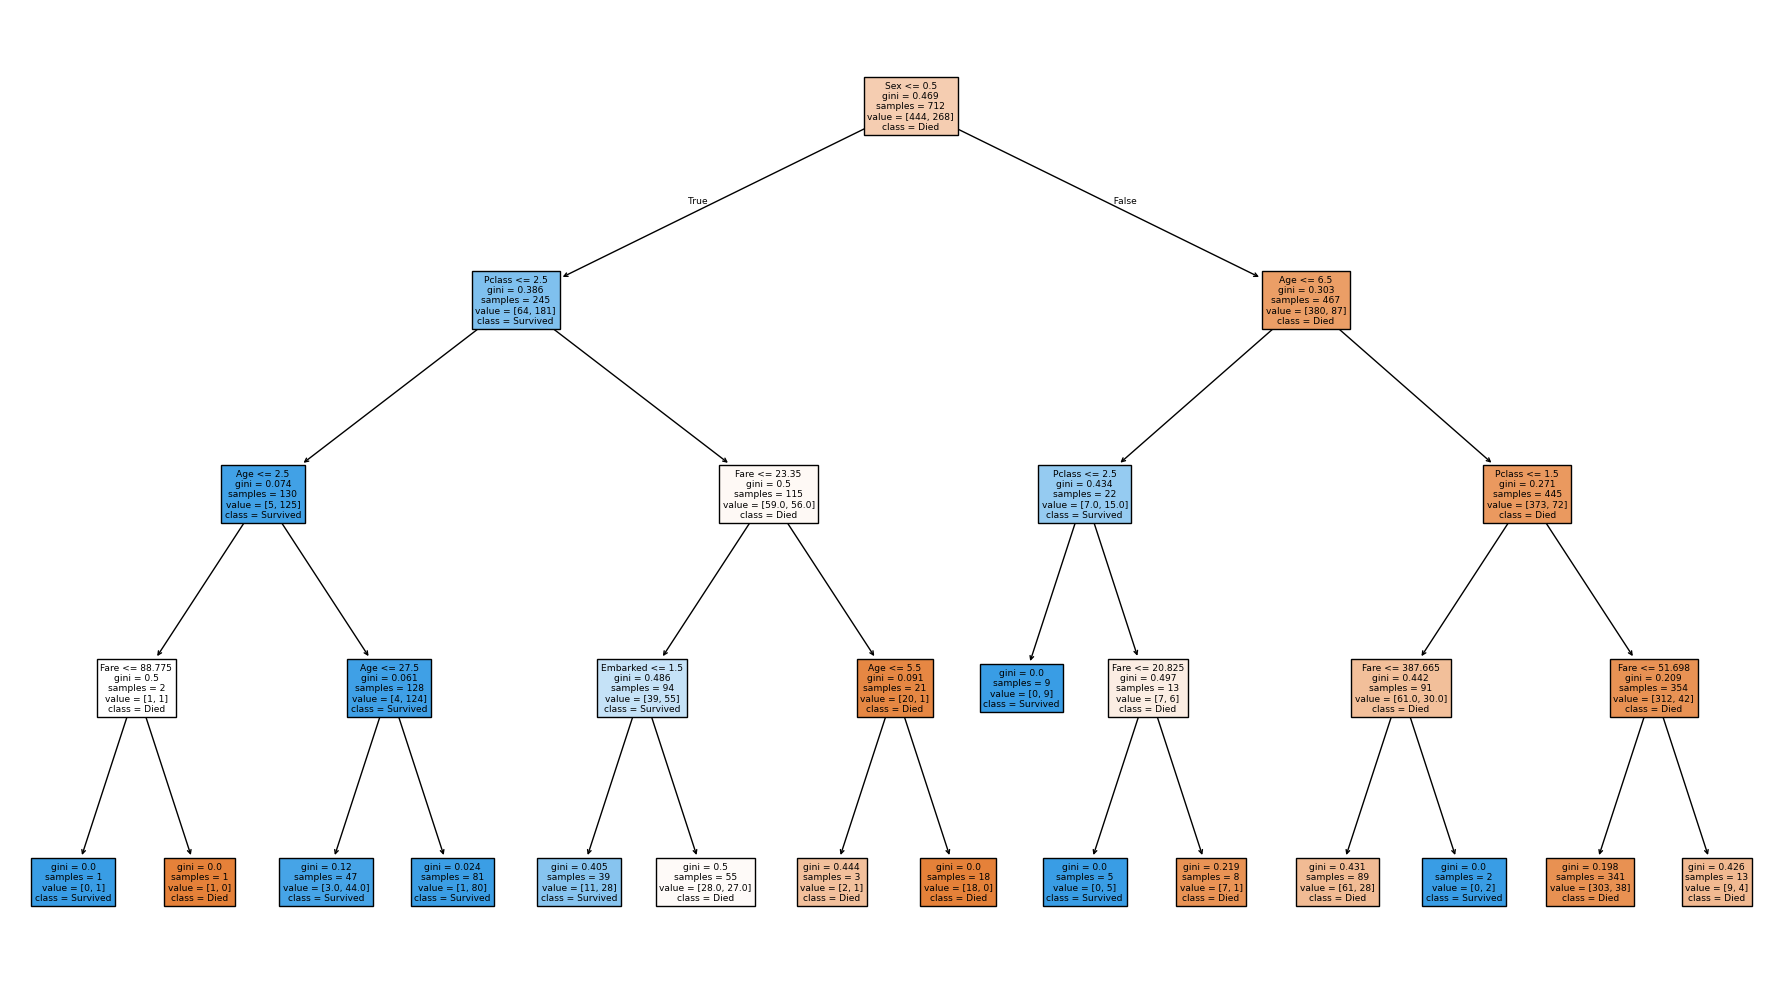

for depth = 5, accuracy=0.7988826815642458
for depth = 6, accuracy=0.8044692737430168
for depth = 7, accuracy=0.7932960893854749
for depth = 8, accuracy=0.7877094972067039


In [60]:
# For maximum depth
max_depths = [2, 3, 4, 5, 6, 7, 8]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy={acc}")

    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(model, feature_names = X.columns, class_names = ["Died", "Survived"], filled=True)
        plt.tight_layout()
        plt.show()


for minimum samples = 5, accuracy=0.7988826815642458
for minimum samples = 10, accuracy=0.7988826815642458


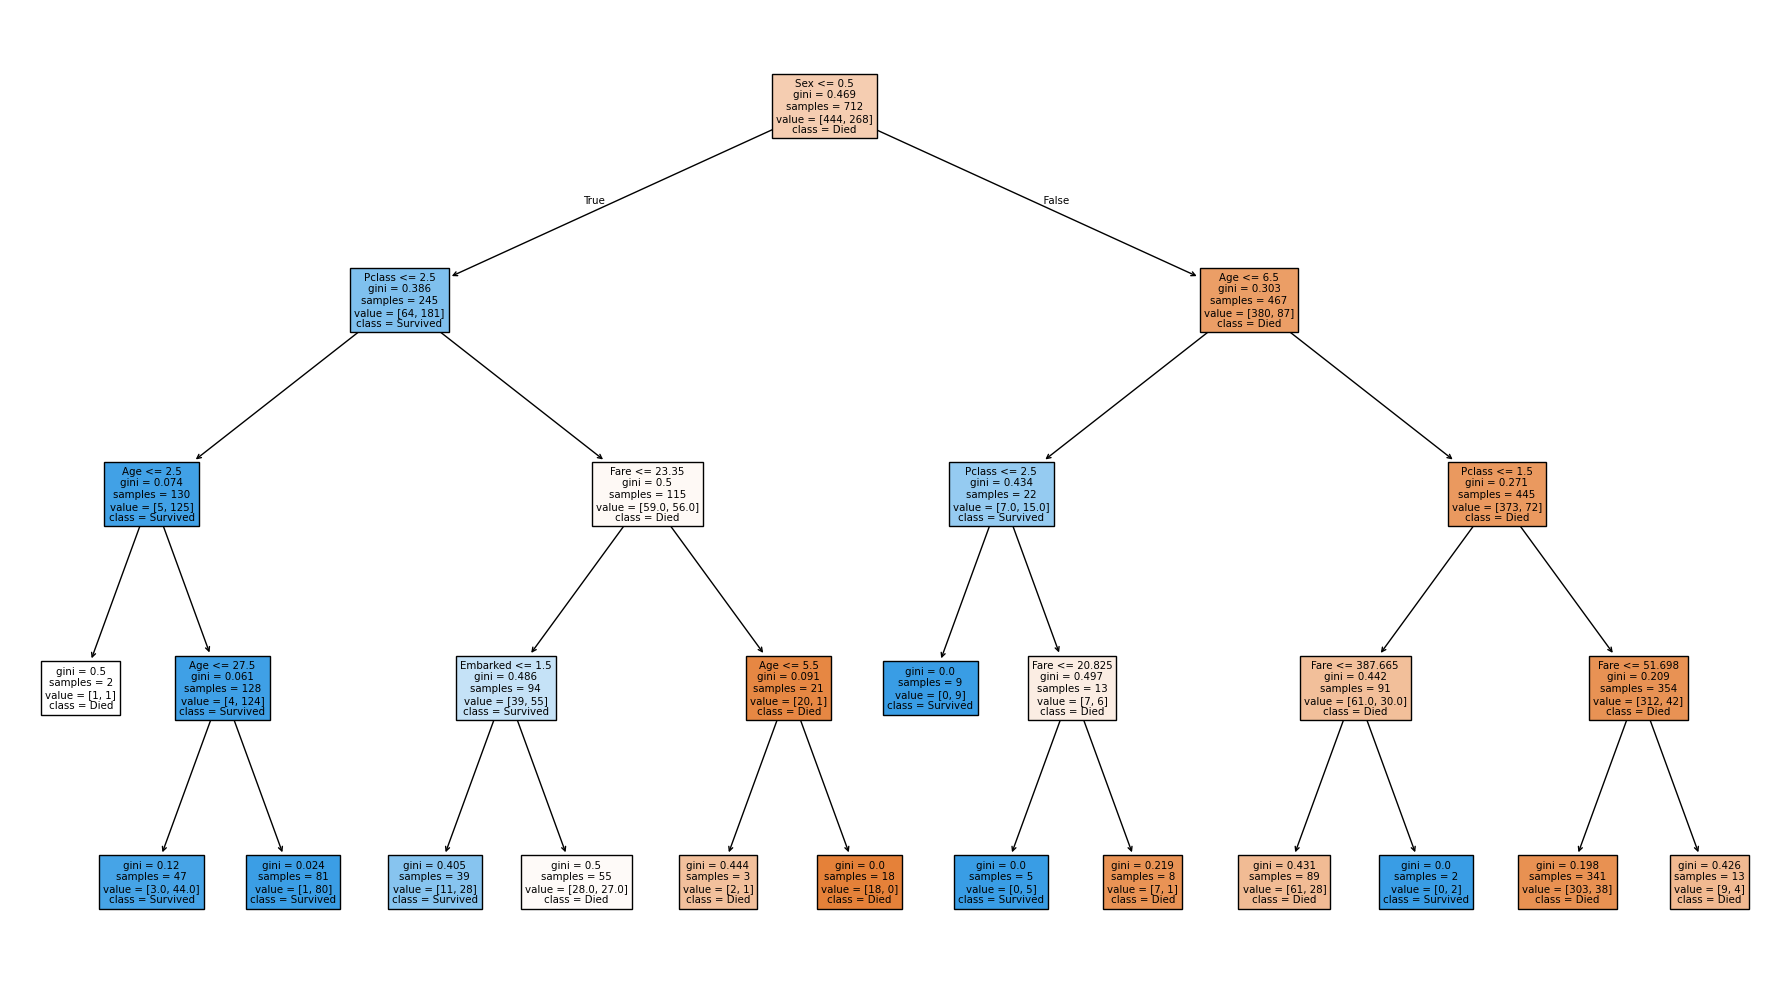

for minimum samples = 15, accuracy=0.7988826815642458
for minimum samples = 20, accuracy=0.7988826815642458
for minimum samples = 25, accuracy=0.7932960893854749
for minimum samples = 30, accuracy=0.7932960893854749
for minimum samples = 35, accuracy=0.7932960893854749
for minimum samples = 40, accuracy=0.7932960893854749


In [61]:
# For minimum samples split
min_samples_split = [5, 10, 15, 20, 25, 30, 35, 40]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for minimum samples = {split}, accuracy={acc}")

    if split == 10:
        plt.figure(figsize=(18,10))
        plot_tree(model, feature_names = X.columns, class_names = ["Died", "Survived"], filled=True)
        plt.tight_layout()
        plt.show()

In [62]:
# Decision Tree with Post-Pruning

full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [63]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [64]:
# Now we train our model for all alpha values here
tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    tree.append((model, alpha))

In [65]:
best_acc = 0
best_model = 0

for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

print("Best Accuracy", best_acc)
print("Best aplha", best_alpha)

Best Accuracy 0.8379888268156425
Best aplha 0.0015407231242023183


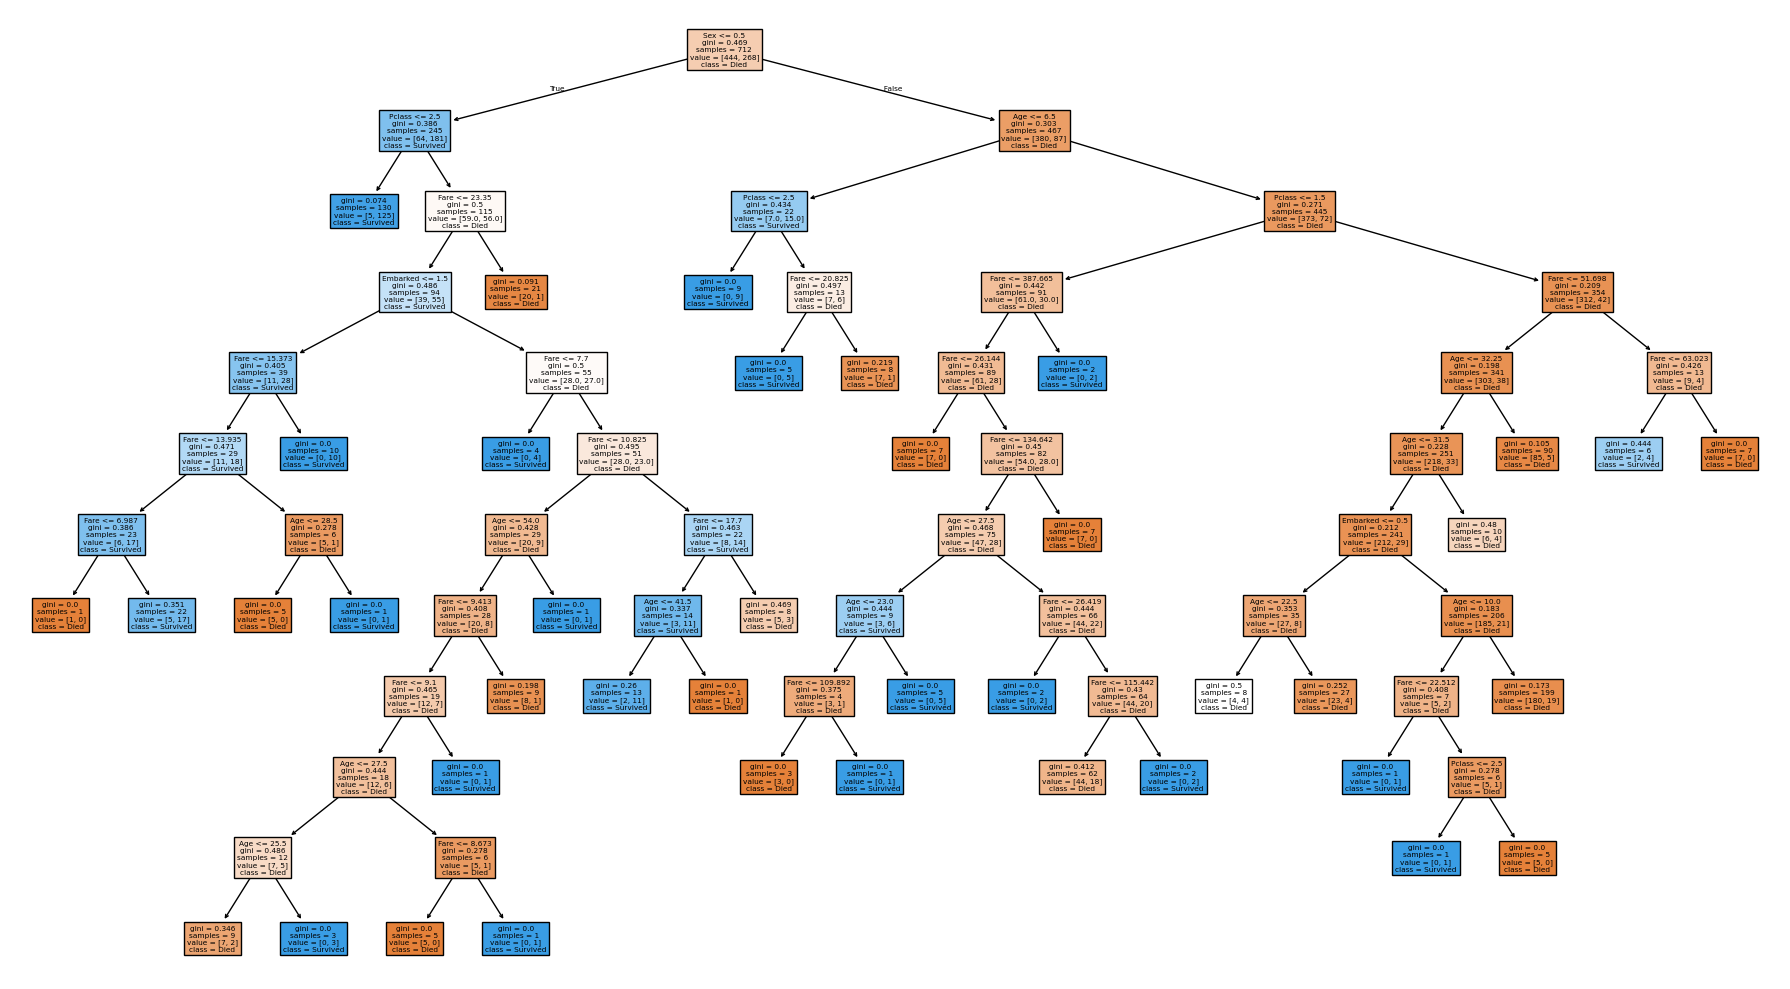

In [67]:
#Now we'll train our model on this

best_model = DecisionTreeClassifier(random_state = 42, ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

plt.figure(figsize=(18,10))
plot_tree(best_model, feature_names = X.columns, class_names = ["Died", "Survived"], filled=True)
plt.tight_layout()
plt.show()

In [68]:
print(best_model.score(X_test, y_test))

0.8379888268156425


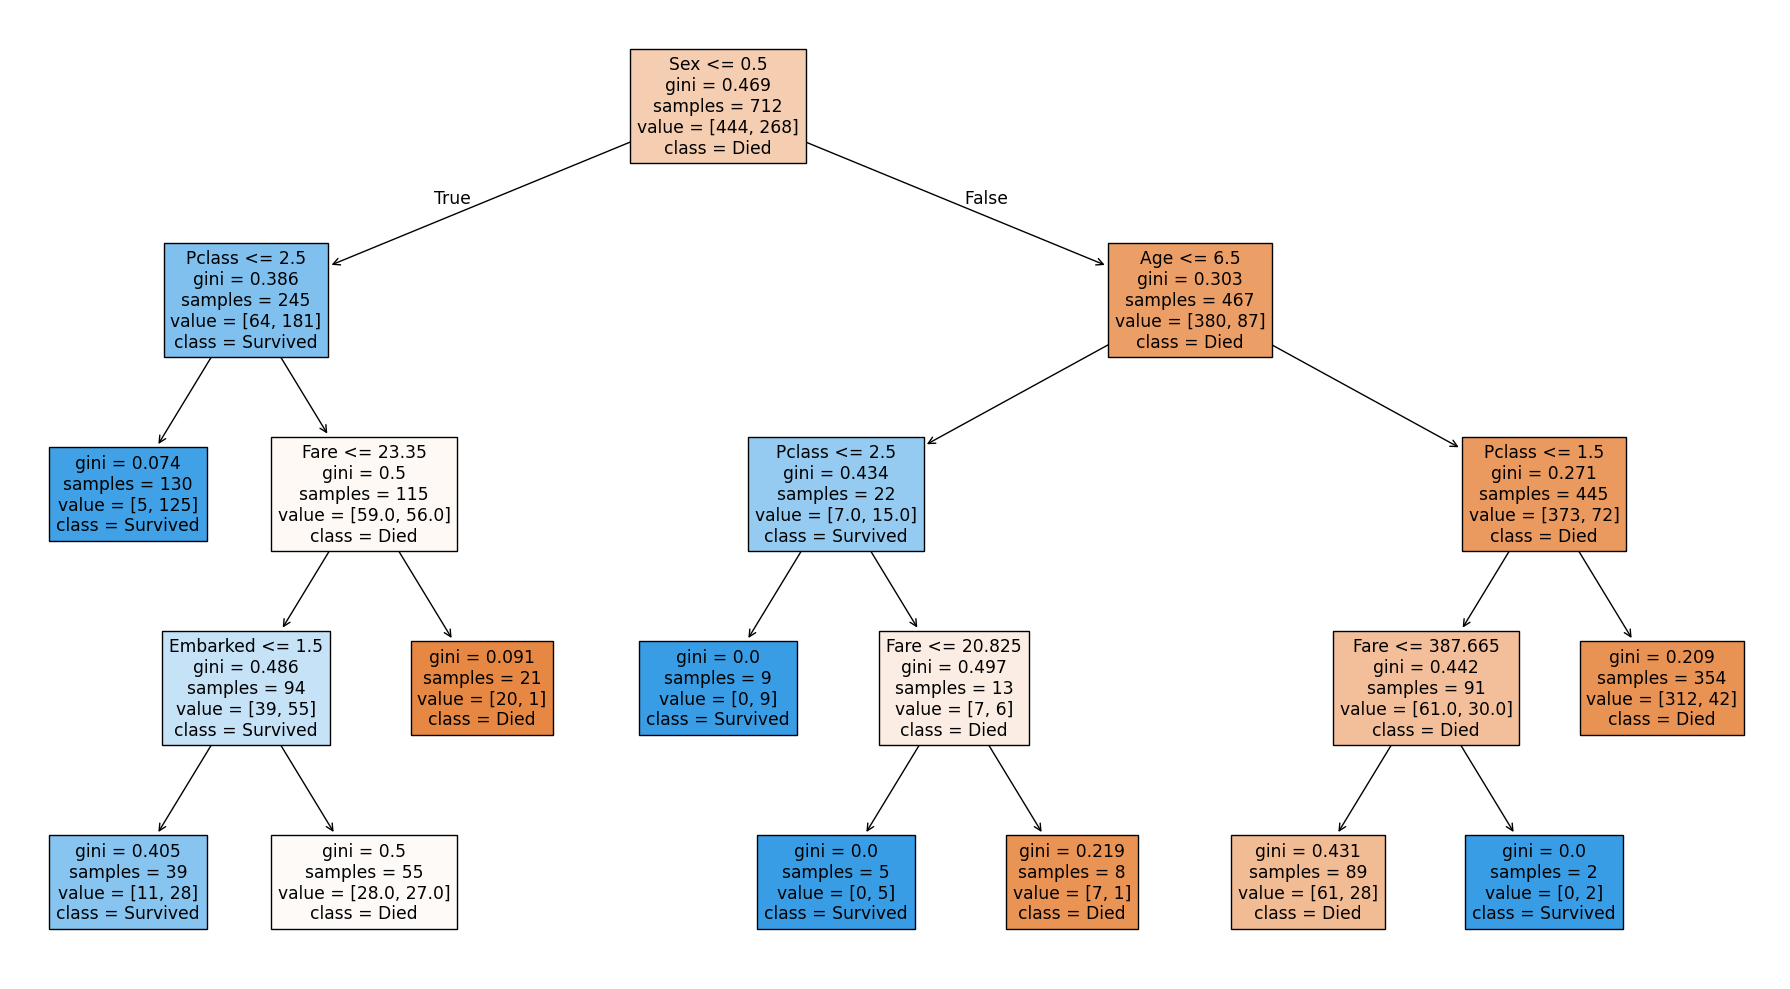

In [ ]:
# Including max_depth here 
best_model = DecisionTreeClassifier(random_state = 42, ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train, y_train)

plt.figure(figsize=(18,10))
plot_tree(best_model, feature_names = X.columns, class_names = ["Died", "Survived"], filled=True)
plt.tight_layout()
plt.show()

In [ ]:
print(best_model.score(X_test, y_test)) # Can see a decline in accuracy

0.7988826815642458
